# 02 · Local Inference with Transformers (the observable runtime)

`mlx` and `llama.cpp` are faster, but Hugging Face Transformers on PyTorch is the runtime you can **see inside**. In this notebook we:

1. Load a small instruct model on **MPS** through `llmlab.models.local_model.LocalModel`.
2. **Generate** greedily and **stream** token-by-token.
3. Expose a single **forward pass** — logits, hidden states, and attention weights.
4. Inspect the **KV cache** and what it costs per token.
5. Re-implement decoding by hand and prove `greedy_decode` reproduces `model.generate` **token-for-token**.

Reusable code lives in `llmlab/models/local_model.py`; tests in `tests/test_local_model.py`."

In [ ]:
import sys
from pathlib import Path

# Make the local `llmlab` package importable when running from notebooks/.
LLM_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(LLM_DIR) not in sys.path:
    sys.path.insert(0, str(LLM_DIR))

import warnings
warnings.filterwarnings("ignore")  # keep teaching output clean
import transformers
transformers.logging.set_verbosity_error()

import torch
from llmlab import config
from llmlab.models.local_model import (
    LocalModel,
    SamplingConfig,
    greedy_decode,
    kv_cache_shapes,
)

config.configure_caches()
config.ensure_dirs()
config.seed_everything(0)
print("device:", config.get_device(), "| torch:", torch.__version__)

device: mps | torch: 2.12.1


## 1. Load a model — the observable runtime

We load with `attn_implementation="eager"`, which is required to read attention weights back out (the faster `sdpa` / `flash` kernels don't return them). The model is small (~0.5B parameters) so a float32 load is comfortable in unified memory. The architecture summary below is what every later notebook builds on: layer count, head counts, and `head_dim`.

In [ ]:
# Pin float32 for a deterministic, easy-to-reason-about baseline. (transformers
# now loads a checkpoint's native dtype by default — here that would be bf16.)
lm = LocalModel("Qwen/Qwen2.5-0.5B-Instruct", dtype="float32")
cfg = lm.model.config
n_params = sum(p.numel() for p in lm.model.parameters())

print(f"model  : {lm.model_id}")
print(f"device : {lm.device}")
print(f"dtype  : {next(lm.model.parameters()).dtype}")
print(f"params : {n_params/1e6:.0f}M")

arch = {
    "n_layers": cfg.num_hidden_layers,
    "hidden_size": cfg.hidden_size,
    "n_query_heads": cfg.num_attention_heads,
    "n_kv_heads": getattr(cfg, "num_key_value_heads", cfg.num_attention_heads),
    "head_dim": getattr(cfg, "head_dim", cfg.hidden_size // cfg.num_attention_heads),
    "vocab_size": cfg.vocab_size,
    "max_position_embeddings": getattr(cfg, "max_position_embeddings", None),
}
arch

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

model  : Qwen/Qwen2.5-0.5B-Instruct
device : mps
dtype  : torch.float32
params : 494M


{'n_layers': 24,
 'hidden_size': 896,
 'n_query_heads': 14,
 'n_kv_heads': 2,
 'head_dim': 64,
 'vocab_size': 151936,
 'max_position_embeddings': 32768}

## 2. Generate, then stream

`generate()` returns the whole completion at once; `stream()` yields chunks as they are produced (a background thread feeds a `TextIteratorStreamer`). Both go through the same clean-greedy `SamplingConfig`, so a model's bundled `generation_config` can't silently switch sampling on.

In [ ]:
messages = [{"role": "user", "content": "Explain what a KV cache is in one sentence."}]

res = lm.generate(messages, SamplingConfig(max_new_tokens=48))
print("GREEDY:\n", res.text)
print(f"\n[{res.new_tokens} new tokens from a {res.prompt_tokens}-token prompt]")

print("\nSTREAMING (same settings, token-by-token):")
for chunk in lm.stream(messages, SamplingConfig(max_new_tokens=48)):
    print(chunk, end="", flush=True)
print()

GREEDY:
 A KV cache is a type of memory-based data storage system that stores key-value pairs, allowing for quick retrieval of data based on keys, and provides a fast and efficient way to store and retrieve data in a distributed computing environment.

[47 new tokens from a 40-token prompt]

STREAMING (same settings, token-by-token):


A 

KV 

cache 

is 

...

in 

a 

distributed 

computing 

environment.

## 3. One forward pass, exposed

A single `forward()` with `output_attentions=True, output_hidden_states=True` hands back the model's internals. The shapes tell the story: hidden states for the embedding layer **plus** every block, attention weights of shape `(batch, heads, query, key)`, and a logit vector over the whole vocabulary at every position. The last position's logits are the model's prediction for the *next* token.

In [ ]:
import torch.nn.functional as F

inputs, outputs = lm.forward(messages, output_attentions=True, output_hidden_states=True)
seq_len = inputs["input_ids"].shape[-1]

print(f"prompt length        : {seq_len} tokens")
print(f"logits shape         : {tuple(outputs.logits.shape)}  (batch, seq, vocab)")
print(f"hidden_states tensors: {len(outputs.hidden_states)}  (embeddings + {cfg.num_hidden_layers} blocks)")
print(f"each hidden state    : {tuple(outputs.hidden_states[0].shape)}")
print(f"attention tensors    : {len(outputs.attentions)}")
print(f"each attention       : {tuple(outputs.attentions[0].shape)}  (batch, heads, query, key)")

# The final position's logits are the next-token distribution.
last_logits = outputs.logits[0, -1]
probs = F.softmax(last_logits, dim=-1)
topk = torch.topk(probs, 5)
print("\nTop-5 next-token predictions:")
for p, tid in zip(topk.values.tolist(), topk.indices.tolist()):
    print(f"  {p:6.2%}  {lm.tokenizer.decode([tid])!r}")

prompt length        : 40 tokens
logits shape         : (1, 40, 151936)  (batch, seq, vocab)
hidden_states tensors: 25  (embeddings + 24 blocks)
each hidden state    : (1, 40, 896)
attention tensors    : 24
each attention       : (1, 14, 40, 40)  (batch, heads, query, key)



Top-5 next-token predictions:
  99.45%  'A'
   0.10%  'KV'
   0.09%  'K'
   0.08%  'In'
   0.06%  'An'


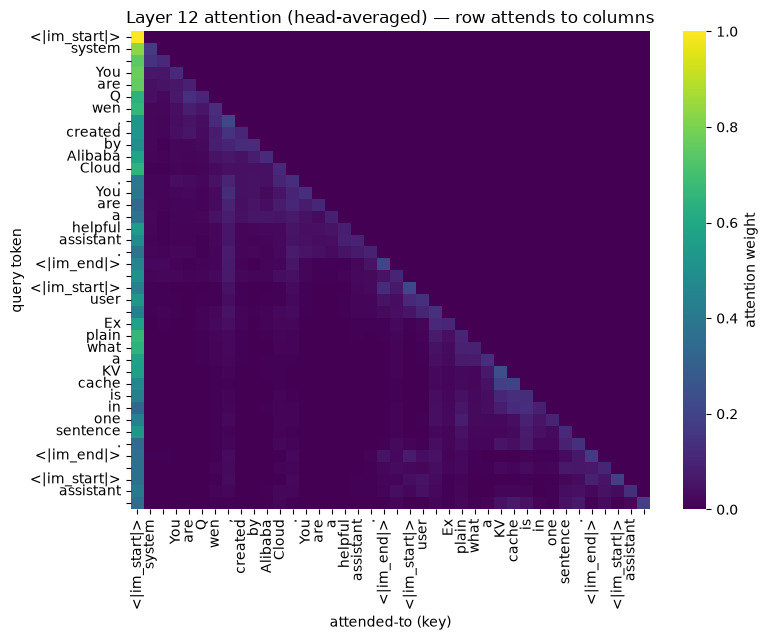

In [ ]:
# Visualise one middle layer's attention (averaged over heads). The strict
# lower-triangular shape is the causal mask: a token can only attend backwards.
import matplotlib.pyplot as plt
import seaborn as sns

layer = cfg.num_hidden_layers // 2
attn = outputs.attentions[layer][0].mean(dim=0).float().cpu().numpy()  # (query, key)
labels = [lm.tokenizer.decode([t]) for t in inputs["input_ids"][0].tolist()]

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(attn, xticklabels=labels, yticklabels=labels, cmap="viridis",
            ax=ax, cbar_kws={"label": "attention weight"})
ax.set_title(f"Layer {layer} attention (head-averaged) — row attends to columns")
ax.set_xlabel("attended-to (key)")
ax.set_ylabel("query token")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 4. The KV cache

During incremental decoding the model caches the keys and values of every past token so it never recomputes them. This cache is the dominant memory cost of long contexts — and the central object of this lab's memory research (Notebook 05 goes deep). Note the **GQA** (grouped-query attention) effect below: far fewer key/value heads than query heads, which shrinks the cache.

In [ ]:
shapes = kv_cache_shapes(outputs.past_key_values)
(_, kv_heads, cached_seq, head_dim) = shapes[0][0]
n_layers = len(shapes)

print(f"layers in cache       : {n_layers}")
print(f"layer-0 key shape     : {shapes[0][0]}  (batch, kv_heads, seq, head_dim)")
print(f"layer-0 value shape   : {shapes[0][1]}")

dtype_bytes = torch.finfo(next(lm.model.parameters()).dtype).bits // 8
kv_bytes_per_token = 2 * n_layers * kv_heads * head_dim * dtype_bytes  # keys + values

print(f"\nGQA: {kv_heads} key/value heads vs {cfg.num_attention_heads} query heads")
print(f"KV cache grows ~{kv_bytes_per_token/1024:.1f} KiB per token (at {dtype_bytes*8}-bit)")
print(f"=> a 32k-token context ≈ {kv_bytes_per_token*32768/1e9:.2f} GB of KV cache")
print(f"   (fp16 inference would halve this to ≈ {kv_bytes_per_token*32768/2e9:.2f} GB)")

layers in cache       : 24
layer-0 key shape     : (1, 2, 40, 64)  (batch, kv_heads, seq, head_dim)
layer-0 value shape   : (1, 2, 40, 64)

GQA: 2 key/value heads vs 14 query heads
KV cache grows ~24.0 KiB per token (at 32-bit)
=> a 32k-token context ≈ 0.81 GB of KV cache
   (fp16 inference would halve this to ≈ 0.40 GB)


## 5. Hand-written greedy decode == `model.generate`

The payoff. Decoding is just: forward → take the last position's logits → `argmax` → append the token → feed that one new token back (the rest lives in the KV cache). We do three steps by hand to see the mechanics, then run the full `greedy_decode` from `llmlab` and assert it matches `model.generate` **exactly**.

> **Gotcha — `generation_config` bites.** Many models ship a `generation_config` with `do_sample=True` and a `repetition_penalty` (Qwen2.5 uses `1.05`). Calling `generate(do_sample=False)` *alone* is **not** pure greedy — you must also pass `repetition_penalty=1.0`. That is exactly what our clean-greedy path does, which is why the two agree.

In [ ]:
inputs = lm.to_input(messages)
input_ids = inputs["input_ids"]
mask = inputs.get("attention_mask")

# --- teach the mechanics: decode 3 tokens by hand ---
print("Manual decode, first 3 steps:")
ids, past, cur, cur_mask = input_ids, None, input_ids, mask
for step in range(3):
    with torch.no_grad():
        out = lm.model(input_ids=cur, attention_mask=cur_mask,
                       past_key_values=past, use_cache=True)
    past = out.past_key_values
    nxt = out.logits[:, -1, :].argmax(-1, keepdim=True)
    print(f"  step {step}: token {nxt.item():>6}  -> {lm.tokenizer.decode(nxt[0])!r}")
    ids = torch.cat([ids, nxt], dim=-1)
    cur = nxt  # only the new token; everything else is cached in `past`
    if cur_mask is not None:
        cur_mask = torch.cat([cur_mask, torch.ones_like(nxt)], dim=-1)

# --- full run: our greedy_decode vs HF generate (both clean greedy) ---
reference = lm.model.generate(
    **inputs, max_new_tokens=40, do_sample=False,
    repetition_penalty=1.0, num_beams=1, pad_token_id=lm.tokenizer.eos_token_id,
)
ours = greedy_decode(
    lm.model, input_ids, attention_mask=mask,
    max_new_tokens=40, eos_token_id=lm.tokenizer.eos_token_id,
)
greedy_matches = reference[0].tolist() == ours[0].tolist()
print(f"\ngreedy_decode == model.generate : {greedy_matches}")
assert greedy_matches, "hand-written greedy diverged from model.generate"
print("decoded:", lm.tokenizer.decode(ours[0, input_ids.shape[-1]:], skip_special_tokens=True))

Manual decode, first 3 steps:
  step 0: token     32  -> 'A'
  step 1: token  84648  -> ' KV'
  step 2: token   6500  -> ' cache'



greedy_decode == model.generate : True
decoded: A KV cache is a type of memory-based data storage system that stores key-value pairs, allowing for quick retrieval of data based on keys, and provides a fast and efficient way to store and retrieve data


In [ ]:
import json

summary = {
    "model": lm.model_id,
    "device": lm.device,
    "n_params_m": round(n_params / 1e6),
    "n_layers": n_layers,
    "n_query_heads": cfg.num_attention_heads,
    "n_kv_heads": kv_heads,
    "head_dim": head_dim,
    "kv_bytes_per_token": kv_bytes_per_token,
    "greedy_matches_generate": bool(greedy_matches),
}
path = config.RESULTS_DIR / "02_local_inference_transformers.json"
path.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print("\nwrote", path)

{
  "model": "Qwen/Qwen2.5-0.5B-Instruct",
  "device": "mps",
  "n_params_m": 494,
  "n_layers": 24,
  "n_query_heads": 14,
  "n_kv_heads": 2,
  "head_dim": 64,
  "kv_bytes_per_token": 24576,
  "greedy_matches_generate": true
}

wrote /Users/iali/workplace/projects/personal/ml-notes/docs/LLM/results/02_local_inference_transformers.json
